<a href="https://colab.research.google.com/github/chandanaputtaswamy/Crop-Desease-Detection-VisionTransformer/blob/main/Final_Training_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install timm --quiet

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os

DATA_ROOT = "/content/drive/MyDrive/CropDiseaseProject/final_dataset"

if not os.path.isdir(DATA_ROOT):
    DATA_ROOT = None
    for root, dirs, files in os.walk('/content/drive/MyDrive'):
        if os.path.basename(root) == 'final_dataset' and 'train' in dirs:
            DATA_ROOT = root
            break

assert DATA_ROOT is not None, "Could not find final_dataset in your Drive"
print("Using dataset at:", DATA_ROOT)

Mounted at /content/drive
Using dataset at: /content/drive/MyDrive/CropDiseaseProject/final_dataset


In [4]:
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected — go to Runtime > Change runtime type > T4 GPU, then rerun from Cell 1.")

torch.backends.cudnn.benchmark = True

CUDA available: True
GPU: Tesla T4


In [7]:
import shutil, time

LOCAL_ROOT = "/content/final_dataset"

if not os.path.isdir(LOCAL_ROOT):
    print("Copying dataset to local disk (one-time cost, then training reads are fast)...")
    start = time.time()
    shutil.copytree(DATA_ROOT, LOCAL_ROOT)
    print(f"Done in {time.time()-start:.1f}s")
else:
    print("Local copy already exists.")

TRAIN_DIR = os.path.join(LOCAL_ROOT, "train")
VAL_DIR = os.path.join(LOCAL_ROOT, "validation")
TEST_DIR = os.path.join(LOCAL_ROOT, "test")

Local copy already exists.


In [11]:
import os

# Dataset is already loaded in local storage
LOCAL_ROOT = "/content/final_dataset"

# Assign folder paths
TRAIN_DIR = os.path.join(LOCAL_ROOT, "train")
VALID_DIR = os.path.join(LOCAL_ROOT, "valid")
TEST_DIR = os.path.join(LOCAL_ROOT, "test")

# Verify the structure
print("Dataset structure:")

for name, path in [
    ("Train", TRAIN_DIR),
    ("Validation", VALID_DIR),
    ("Test", TEST_DIR)
]:
    print(f"{name}: {'✓ EXISTS' if os.path.isdir(path) else '✗ MISSING'}")

print("\nDataset root:", LOCAL_ROOT)

Dataset structure:
Train: ✗ MISSING
Validation: ✗ MISSING
Test: ✓ EXISTS

Dataset root: /content/final_dataset


In [12]:
for name, path in [
    ("Train", TRAIN_DIR),
    ("Validation", VAL_DIR),
    ("Test", TEST_DIR)
]:
    if os.path.isdir(path):
        count = sum(
            1 for root, dirs, files in os.walk(path)
            if any(f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp")) for f in files)
        )
        print(f"{name}: {count} folders/files detected")

Test: 12 folders/files detected


In [13]:
import os

LOCAL_ROOT = "/content/final_dataset"

print("Everything inside LOCAL_ROOT:")
for item in os.listdir(LOCAL_ROOT):
    full_path = os.path.join(LOCAL_ROOT, item)
    print("📁" if os.path.isdir(full_path) else "📄", item)

Everything inside LOCAL_ROOT:
📁 test


In [15]:
import shutil
import os
import time

LOCAL_ROOT = "/content/final_dataset"

# Copy ONLY the missing folders from Google Drive
for folder in ["train", "validation"]:
    source = os.path.join(DATA_ROOT, folder)
    destination = os.path.join(LOCAL_ROOT, folder)

    if os.path.isdir(destination):
        print(f"{folder} already exists — skipping.")
    else:
        print(f"Copying {folder}...")
        start = time.time()
        shutil.copytree(source, destination)
        print(f"{folder} copied in {time.time() - start:.1f} seconds")

print("\nDone!")

train already exists — skipping.
Copying validation...
validation copied in 32.3 seconds

Done!


In [16]:
TRAIN_DIR = os.path.join(LOCAL_ROOT, "train")
VAL_DIR = os.path.join(LOCAL_ROOT, "validation")
TEST_DIR = os.path.join(LOCAL_ROOT, "test")

print("Train:", os.path.isdir(TRAIN_DIR))
print("Validation:", os.path.isdir(VAL_DIR))
print("Test:", os.path.isdir(TEST_DIR))

Train: True
Validation: True
Test: True


In [17]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

IMG_SIZE = 224          # standard ViT patch16 input size
BATCH_SIZE = 64
VALID_EXTS = {'.jpg', '.jpeg', '.png', '.ppm', '.bmp', '.pgm', '.tif', '.tiff', '.webp'}

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

def list_class_dirs(root):
    return {d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d))}

train_classes = list_class_dirs(TRAIN_DIR)
val_classes = list_class_dirs(VAL_DIR)
test_classes = list_class_dirs(TEST_DIR)

all_classes = sorted(train_classes | val_classes | test_classes)
class_to_idx = {c: i for i, c in enumerate(all_classes)}
class_names = all_classes
NUM_CLASSES = len(all_classes)
print(f"Canonical class list: {NUM_CLASSES} classes.")

class SafeImageFolder(Dataset):
    def __init__(self, root, class_to_idx, transform=None):
        self.transform = transform
        self.class_to_idx = class_to_idx
        self.classes = list(class_to_idx.keys())
        self.samples = []
        for cls, idx in class_to_idx.items():
            cls_dir = os.path.join(root, cls)
            if not os.path.isdir(cls_dir):
                continue
            for fname in sorted(os.listdir(cls_dir)):
                if os.path.splitext(fname)[1].lower() in VALID_EXTS:
                    self.samples.append((os.path.join(cls_dir, fname), idx))
        self.targets = [s[1] for s in self.samples]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        path, label = self.samples[i]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

train_dataset = SafeImageFolder(TRAIN_DIR, class_to_idx, transform=train_transform)
val_dataset = SafeImageFolder(VAL_DIR, class_to_idx, transform=eval_transform)
test_dataset = SafeImageFolder(TEST_DIR, class_to_idx, transform=eval_transform)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=4, pin_memory=True, persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=4, pin_memory=True, persistent_workers=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True, persistent_workers=True)

Canonical class list: 107 classes.
Train: 70139 | Val: 11813 | Test: 1244


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [18]:
import timm
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

MODEL_NAME = "vit_small_patch16_224"   # a genuine Vision Transformer, lighter than ViT-Base/Swin-Base
model = timm.create_model(MODEL_NAME, pretrained=True, num_classes=NUM_CLASSES).to(device)

# Freeze the transformer backbone — only train the classifier head.
# This is what keeps 5 epochs feasible in a few hours instead of 15+.
for param in model.parameters():
    param.requires_grad = False
for param in model.get_classifier().parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")

class_counts = [0] * NUM_CLASSES
for _, label in train_dataset.samples:
    class_counts[label] += 1
class_weights = torch.tensor([1.0 / max(c, 1) for c in class_counts], dtype=torch.float)
class_weights = (class_weights / class_weights.sum() * NUM_CLASSES).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3, weight_decay=0.01
)

NUM_EPOCHS = 5
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=1e-3, steps_per_epoch=len(train_loader), epochs=NUM_EPOCHS
)

scaler = torch.amp.GradScaler("cuda")

Using device: cuda


model.safetensors: reconstructing file:   0%|          |  0.00B / 88.2MB            

model.safetensors: downloading bytes:           |  0.00B            

Trainable params: 41,195 / 21,706,859


In [19]:
import time, copy
from tqdm.auto import tqdm

def run_epoch(loader, train_mode, desc=""):
    model.train() if train_mode else model.eval()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    pbar = tqdm(loader, desc=desc)

    with torch.set_grad_enabled(train_mode):
        for images, labels in pbar:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            if train_mode:
                optimizer.zero_grad()

            with torch.amp.autocast("cuda"):
                outputs = model(images)
                loss = criterion(outputs, labels)

            if train_mode:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()

            preds = outputs.argmax(dim=1)

            total_loss += loss.item() * images.size(0)
            total_correct += (preds == labels).sum().item()
            total_samples += images.size(0)

            pbar.set_postfix(
                loss=total_loss / total_samples,
                acc=total_correct / total_samples
            )

    return total_loss / total_samples, total_correct / total_samples


best_val_acc = 0.0
best_model_state = None

for epoch in range(NUM_EPOCHS):
    start = time.time()

    train_loss, train_acc = run_epoch(
        train_loader,
        train_mode=True,
        desc=f"Epoch {epoch+1} [train]"
    )

    val_loss, val_acc = run_epoch(
        val_loader,
        train_mode=False,
        desc=f"Epoch {epoch+1} [val]"
    )

    print(
        f"Epoch {epoch+1}/{NUM_EPOCHS} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
        f"{time.time()-start:.1f}s"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = copy.deepcopy(model.state_dict())

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch 1 [train]:   0%|          | 0/1096 [00:00<?, ?it/s]

/tmp/ipykernel_1036/2922734051.py:26: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


Epoch 1 [val]:   0%|          | 0/185 [00:00<?, ?it/s]

Epoch 1/5 | train_loss=1.9905 train_acc=0.6685 | val_loss=0.4075 val_acc=0.9027 | 593.1s


...

Epoch 4 [val]:   0%|          | 0/185 [00:00<?, ?it/s]

Epoch 4/5 | train_loss=0.1712 train_acc=0.9591 | val_loss=0.1928 val_acc=0.9488 | 603.1s


Epoch 5 [train]:   0%|          | 0/1096 [00:00<?, ?it/s]

Epoch 5 [val]:   0%|          | 0/185 [00:00<?, ?it/s]

Epoch 5/5 | train_loss=0.1317 train_acc=0.9666 | val_loss=0.1872 val_acc=0.9517 | 590.0s


In [20]:
import torch
from google.colab import files

# Save the BEST model (not just the final epoch)
checkpoint = {
    "model_name": MODEL_NAME,
    "num_classes": NUM_CLASSES,
    "class_names": class_names,
    "model_state_dict": best_model_state,
    "best_val_acc": best_val_acc,
    "img_size": IMG_SIZE
}

MODEL_PATH = "/content/best_vit_crop_disease.pth"

torch.save(checkpoint, MODEL_PATH)

print(f"Model saved to: {MODEL_PATH}")
print(f"Best validation accuracy: {best_val_acc:.4f}")

# Download to your computer
files.download(MODEL_PATH)

Model saved to: /content/best_vit_crop_disease.pth
Best validation accuracy: 0.9517


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
# Restore the BEST model obtained during training
model.load_state_dict(best_model_state)
model.eval()

print(f"Best validation accuracy: {best_val_acc:.4f}")
print("Best model loaded successfully.")

Best validation accuracy: 0.9517
Best model loaded successfully.


In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_recall_fscore_support
)
from tqdm.auto import tqdm

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.amp.autocast("cuda"):
            outputs = model(images)

        predictions = outputs.argmax(dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)

test_accuracy = accuracy_score(all_labels, all_predictions)

print(f"\nTest Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Testing:   0%|          | 0/20 [00:00<?, ?it/s]


Test Accuracy: 0.9807 (98.07%)


In [23]:
report = classification_report(
    all_labels,
    all_predictions,
    labels=list(range(NUM_CLASSES)),
    target_names=class_names,
    zero_division=0
)

print(report)

                                                    precision    recall  f1-score   support

                                Apple___Apple_Scab       0.99      0.92      0.95       109
                                 Apple___Black_Rot       0.99      1.00      0.99        93
                          Apple___Cedar_Apple_Rust       0.95      0.96      0.96        57
                                   Apple___Healthy       1.00      0.98      0.99       260
                       Banana___Bract_Mosaic_Virus       1.00      1.00      1.00        60
                                  Banana___Cordana       1.00      0.99      0.99        83
                                  Banana___Healthy       1.00      1.00      1.00       162
                              Banana___Insect_Pest       1.00      0.99      1.00       103
                                     Banana___Moko       0.98      0.98      0.98        66
                           Banana___Panama_Disease       0.99      0.97      0.

In [24]:
with open("/content/classification_report.txt", "w") as f:
    f.write(report)

print("Classification report saved.")

Classification report saved.



              CONFUSION MATRIX - ViT CROP DISEASE CLASSIFICATION


,0: Apple___Apple_Scab,1: Apple___Black_Rot,2: Apple___Cedar_Apple_Rust,3: Apple___Healthy,4: Banana___Bract_Mosaic_Virus,5: Banana___Cordana,6: Banana___Healthy,7: Banana___Insect_Pest,8: Banana___Moko,9: Banana___Panama_Disease,...,97: Wheat___Aphid,98: Wheat___Black_Rust,99: Wheat___Brown_Leaf_Rust,100: Wheat___Healthy,101: Wheat___Leaf_Blight,102: Wheat___Mite,103: Wheat___Powdery_Mildew,104: Wheat___Scab,105: Wheat___Stem_Fly,106: Wheat___Yellow_Rust
0: Apple___Apple_Scab,100,0,3,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1: Apple___Black_Rot,0,93,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2: Apple___Cedar_Apple_Rust,1,0,55,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3: Apple___Healthy,0,1,0,254,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4: Banana___Bract_Mosaic_Virus,0,0,0,0,60,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102: Wheat___Mite,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
103: Wheat___Powdery_Mildew,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
104: Wheat___Scab,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
105: Wheat___Stem_Fly,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



SUMMARY
Total Test Images      : 1244
Correct Predictions    : 1220
Incorrect Predictions  : 24
Test Accuracy          : 98.07%


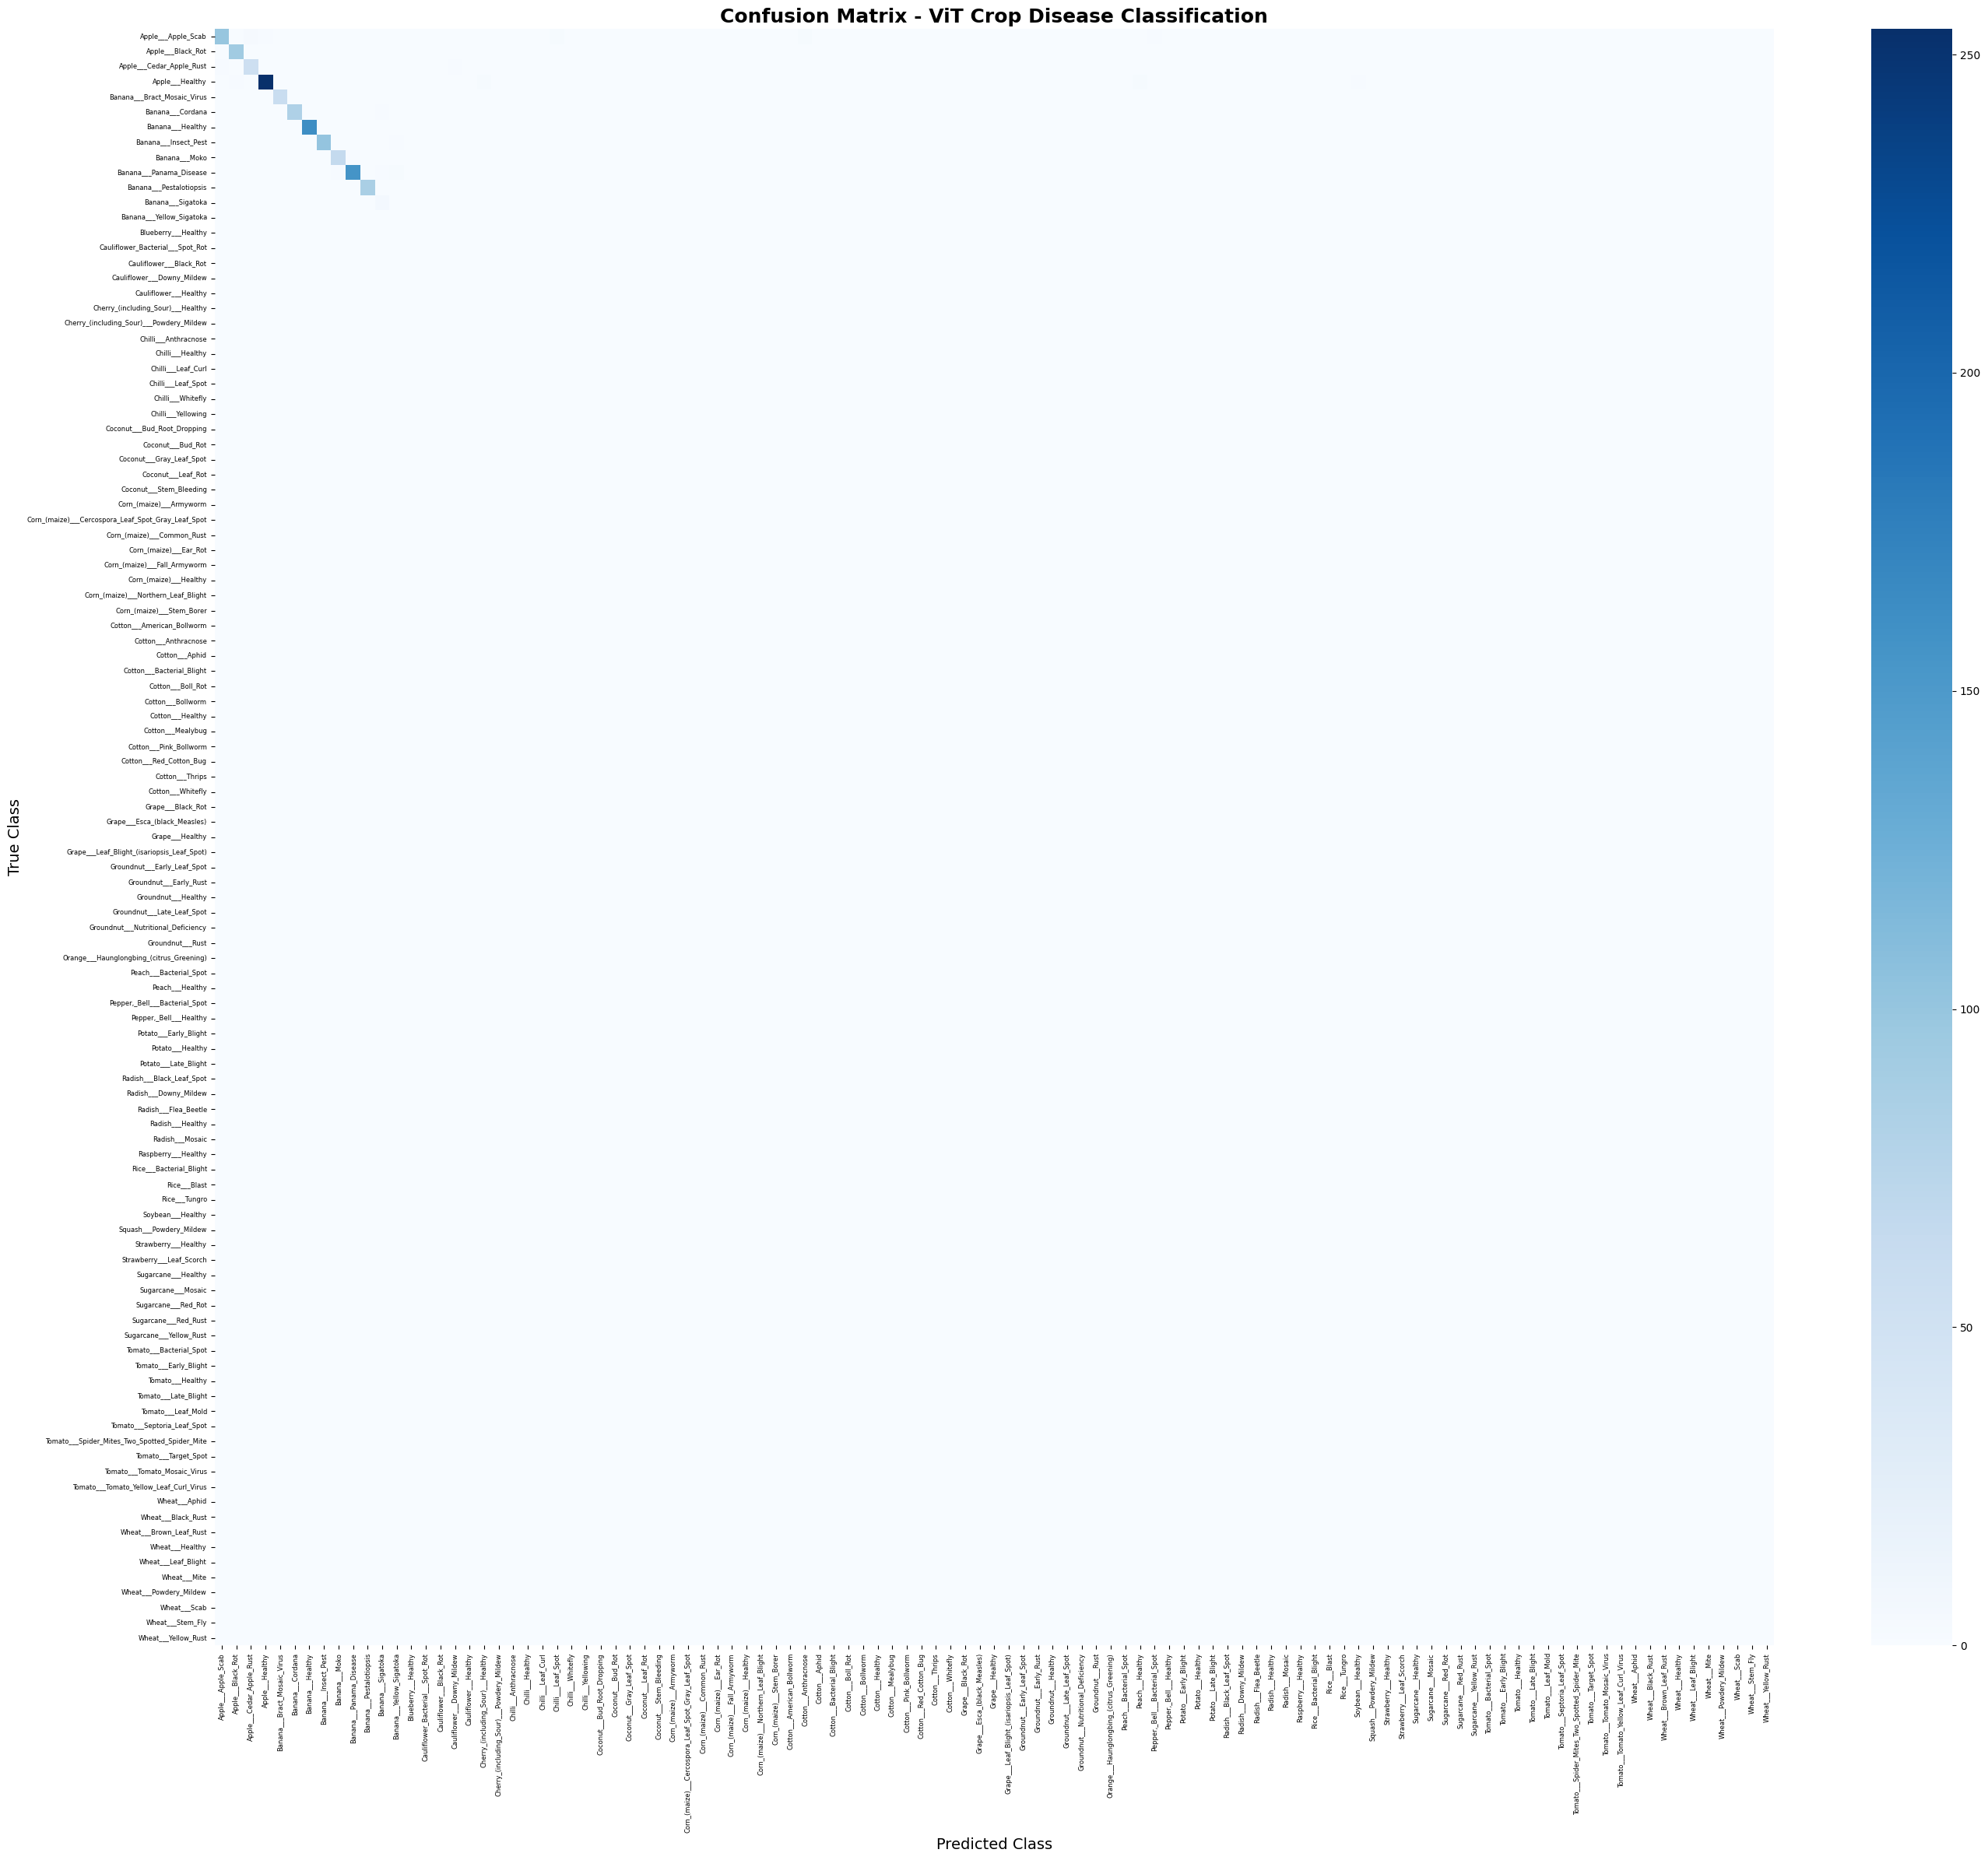


Confusion matrix image saved to:
/content/confusion_matrix.png


In [26]:
# ============================================================
# CONFUSION MATRIX - ViT CROP DISEASE CLASSIFICATION
# ============================================================

from sklearn.metrics import confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate confusion matrix
cm = confusion_matrix(
    all_labels,
    all_predictions,
    labels=list(range(NUM_CLASSES))
)

# ============================================================
# 1. NEATLY PRINT CONFUSION MATRIX
# ============================================================

cm_df = pd.DataFrame(
    cm,
    index=[f"{i}: {name}" for i, name in enumerate(class_names)],
    columns=[f"{i}: {name}" for i, name in enumerate(class_names)]
)

print("\n" + "=" * 120)
print("              CONFUSION MATRIX - ViT CROP DISEASE CLASSIFICATION")
print("=" * 120)

# Display as a clean, scrollable table in Colab
display(cm_df)

print("\n" + "=" * 120)
print("SUMMARY")
print("=" * 120)

total_images = cm.sum()
correct_predictions = cm.diagonal().sum()
incorrect_predictions = total_images - correct_predictions
accuracy = correct_predictions / total_images

print(f"Total Test Images      : {total_images}")
print(f"Correct Predictions    : {correct_predictions}")
print(f"Incorrect Predictions  : {incorrect_predictions}")
print(f"Test Accuracy          : {accuracy * 100:.2f}%")

print("=" * 120)


# ============================================================
# 2. CONFUSION MATRIX HEATMAP
# ============================================================

plt.figure(figsize=(28, 24))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    annot=False,
    cbar=True
)

plt.title(
    "Confusion Matrix - ViT Crop Disease Classification",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Predicted Class", fontsize=14)
plt.ylabel("True Class", fontsize=14)

plt.xticks(
    rotation=90,
    fontsize=6
)

plt.yticks(
    rotation=0,
    fontsize=6
)

plt.tight_layout()

# Save high-resolution image
plt.savefig(
    "/content/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nConfusion matrix image saved to:")
print("/content/confusion_matrix.png")

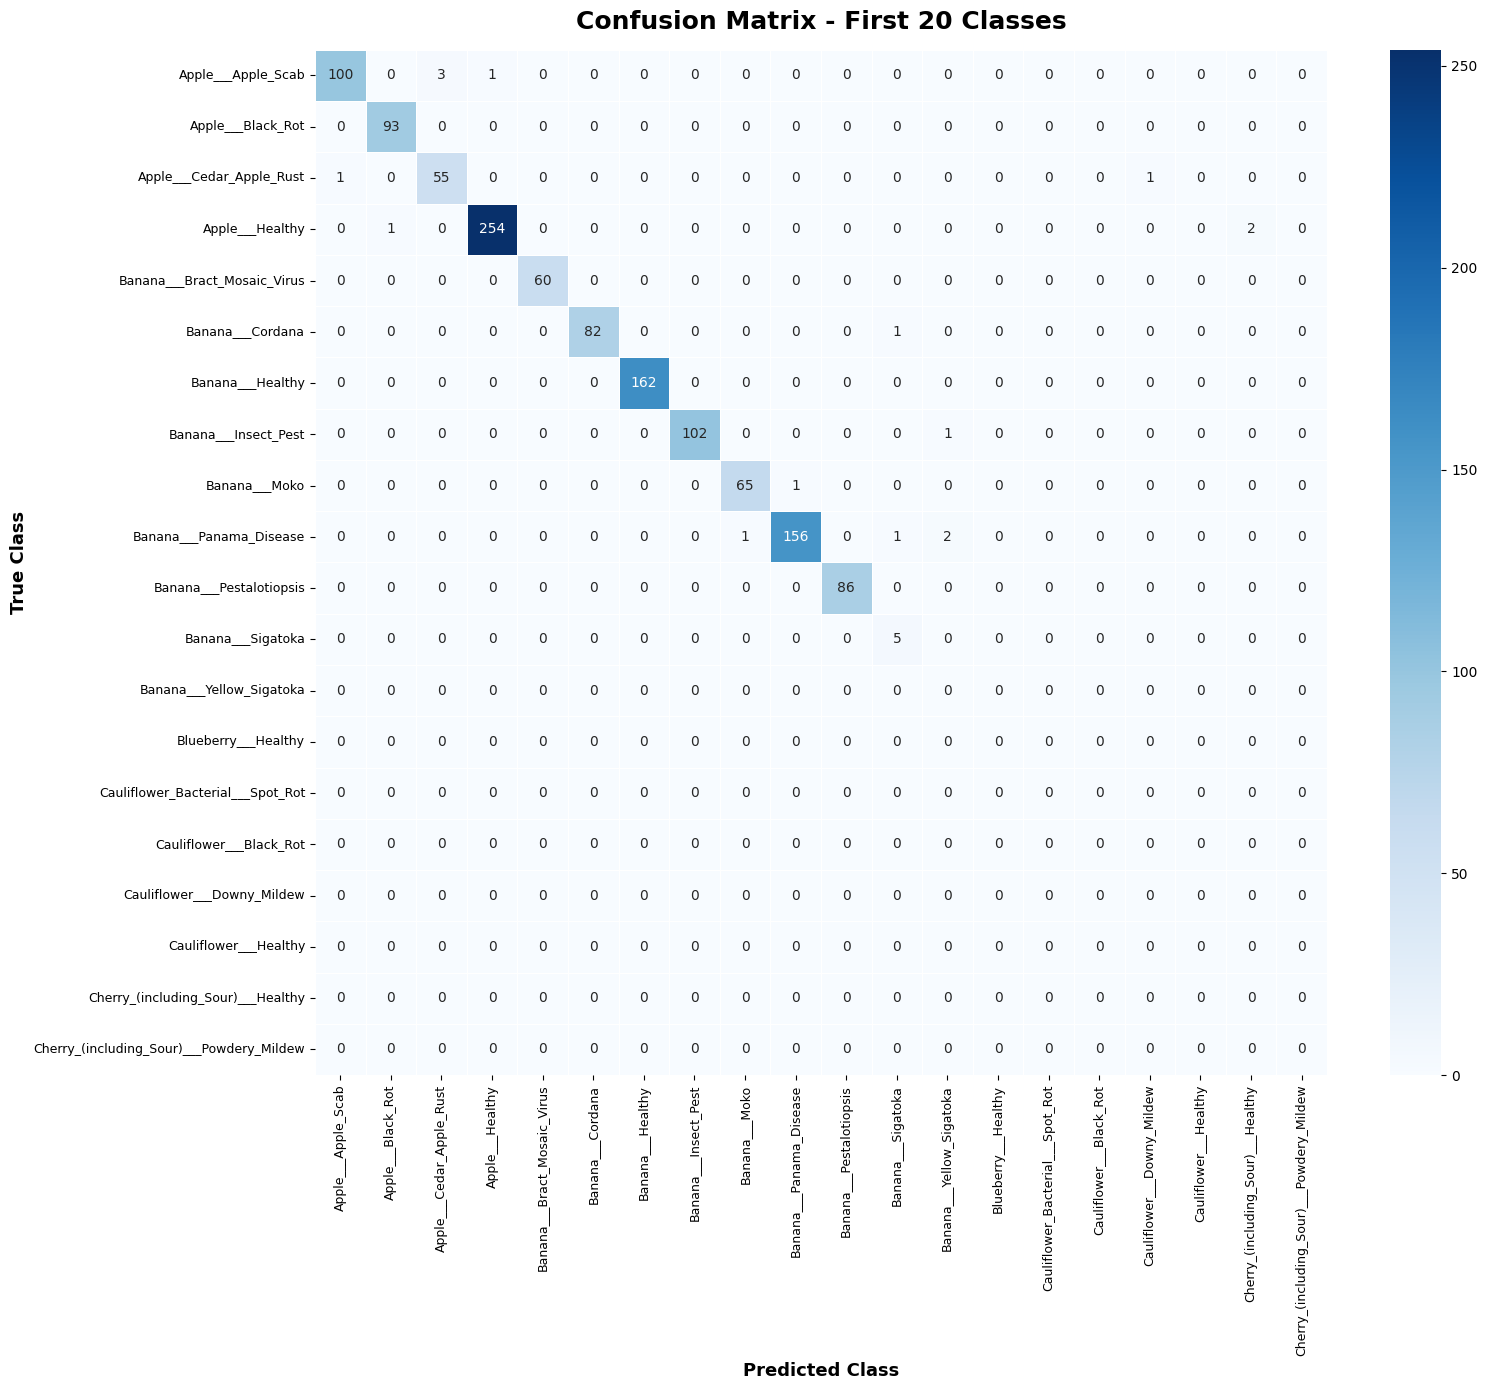

In [27]:
# ============================================================
# CONFUSION MATRIX - DISPLAY ONLY FIRST 20 CLASSES
# ============================================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate full confusion matrix
cm = confusion_matrix(
    all_labels,
    all_predictions,
    labels=list(range(NUM_CLASSES))
)

# Number of classes to display
N = 20

# Take only the first N rows and columns
cm_small = cm[:N, :N]
class_names_small = class_names[:N]

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(16, 14))

sns.heatmap(
    cm_small,
    cmap="Blues",
    xticklabels=class_names_small,
    yticklabels=class_names_small,
    annot=True,              # Show numbers inside cells
    fmt="d",
    linewidths=0.5,
    cbar=True
)

plt.title(
    f"Confusion Matrix - First {N} Classes",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Predicted Class",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "True Class",
    fontsize=13,
    fontweight="bold"
)

plt.xticks(
    rotation=90,
    fontsize=9
)

plt.yticks(
    rotation=0,
    fontsize=9
)

plt.tight_layout()

# Save
plt.savefig(
    "/content/confusion_matrix_first_20.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

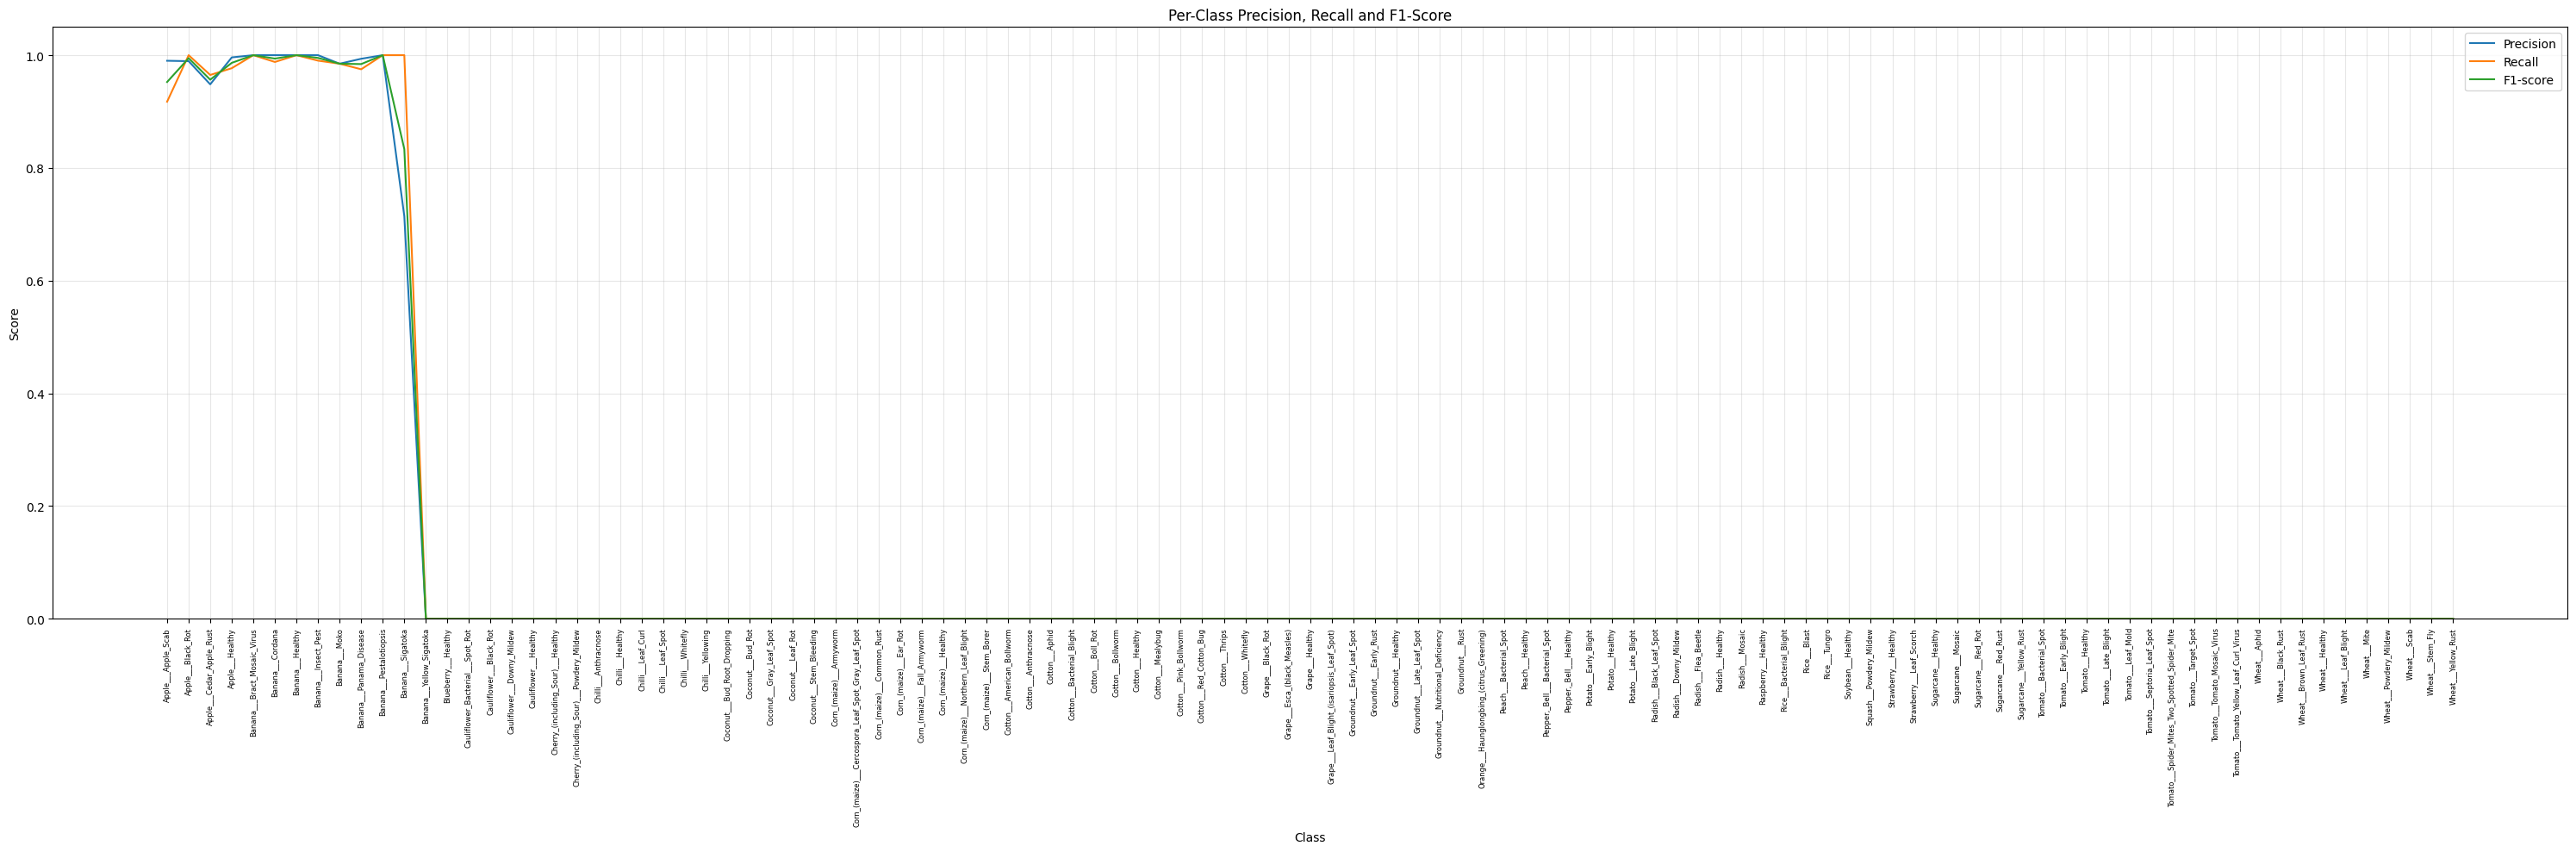

In [29]:
#Per-class performance graph
precision, recall, f1, support = precision_recall_fscore_support(
    all_labels,
    all_predictions,
    labels=list(range(NUM_CLASSES)),
    zero_division=0
)

x = np.arange(NUM_CLASSES)

plt.figure(figsize=(30, 10))

plt.plot(x, precision, label="Precision")
plt.plot(x, recall, label="Recall")
plt.plot(x, f1, label="F1-score")

plt.xlabel("Class")
plt.ylabel("Score")
plt.title("Per-Class Precision, Recall and F1-Score")

plt.xticks(
    x,
    class_names,
    rotation=90,
    fontsize=6
)

plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "/content/per_class_metrics.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

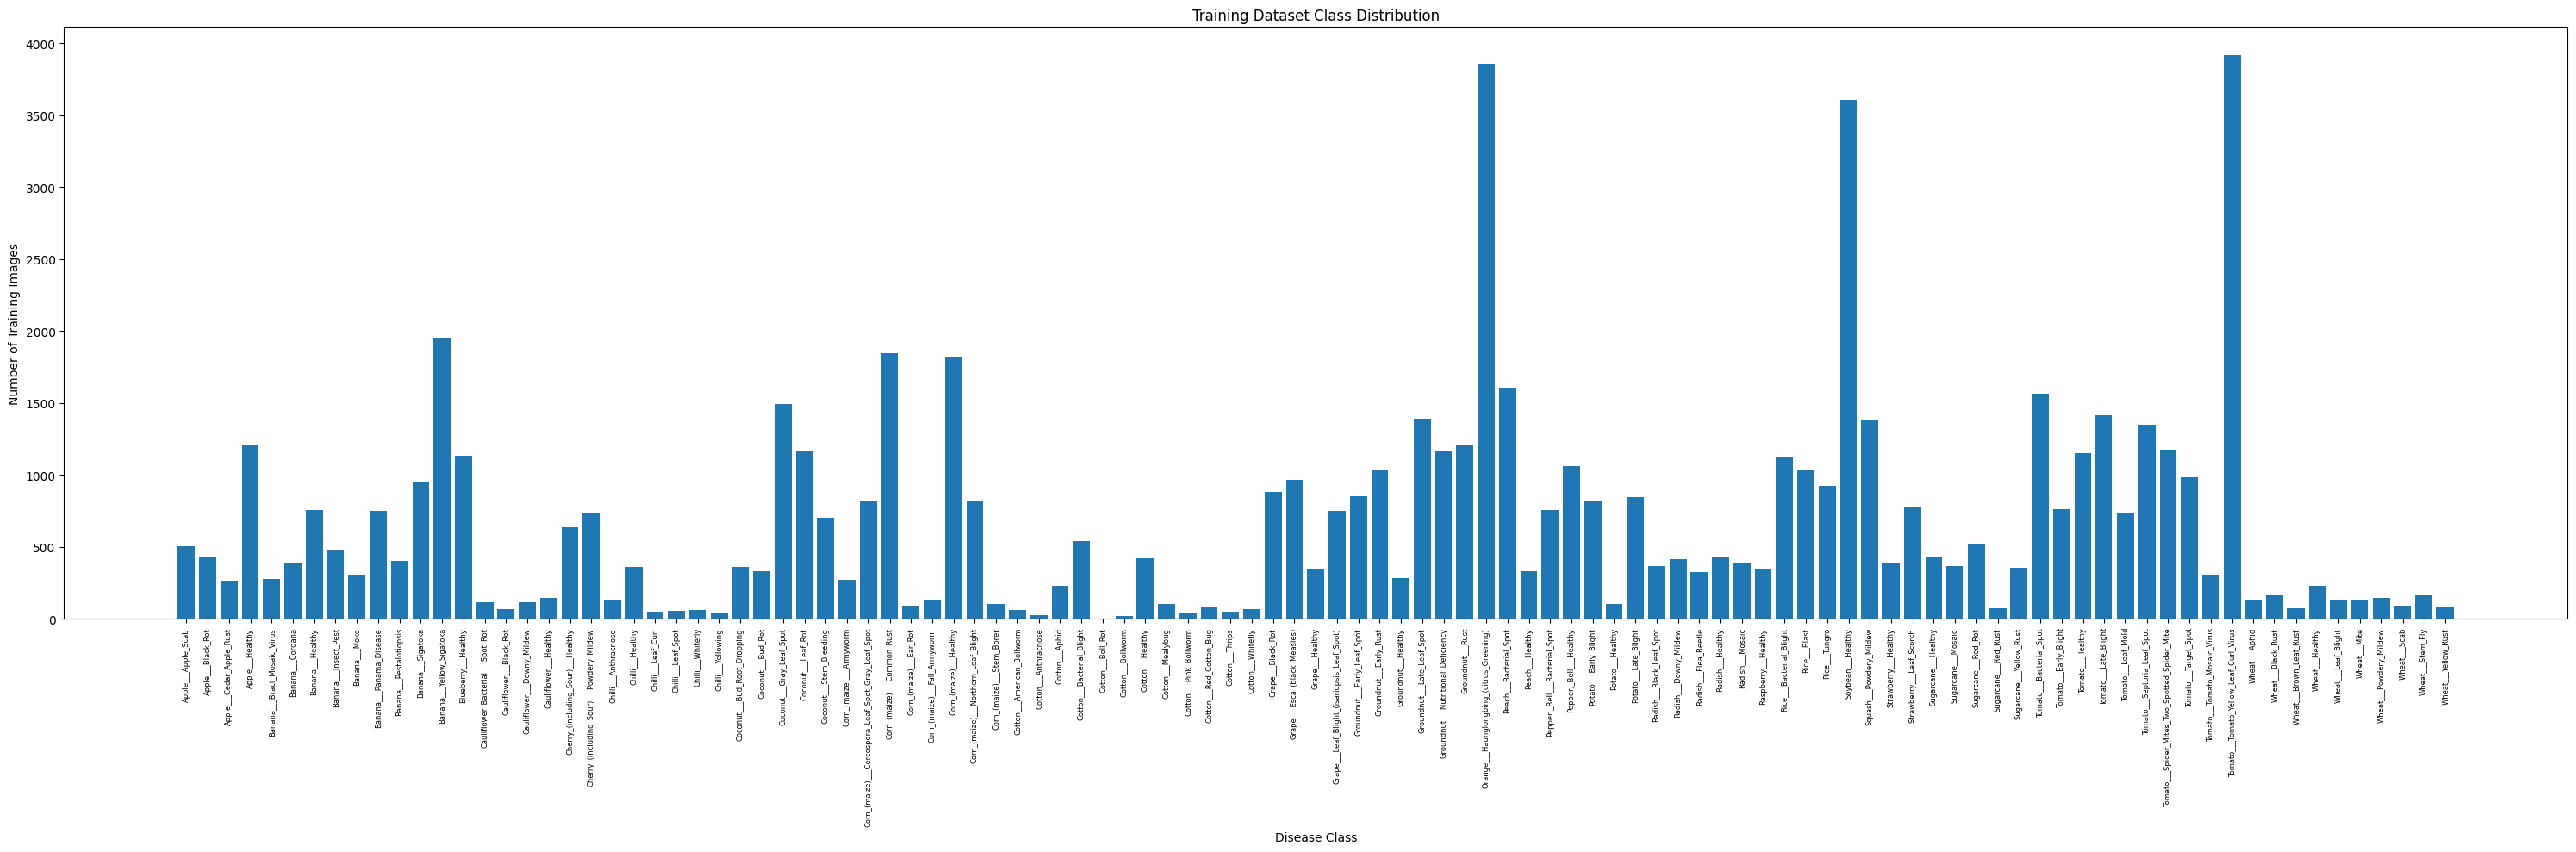

In [30]:
#Class distribution graph
train_counts = np.bincount(
    [label for _, label in train_dataset.samples],
    minlength=NUM_CLASSES
)

plt.figure(figsize=(30, 10))

plt.bar(
    range(NUM_CLASSES),
    train_counts
)

plt.xlabel("Disease Class")
plt.ylabel("Number of Training Images")
plt.title("Training Dataset Class Distribution")

plt.xticks(
    range(NUM_CLASSES),
    class_names,
    rotation=90,
    fontsize=6
)

plt.tight_layout()

plt.savefig(
    "/content/class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Saving mendeley__Banana___Bract_Mosaic_Virus__0003502.jpg to mendeley__Banana___Bract_Mosaic_Virus__0003502 (1).jpg


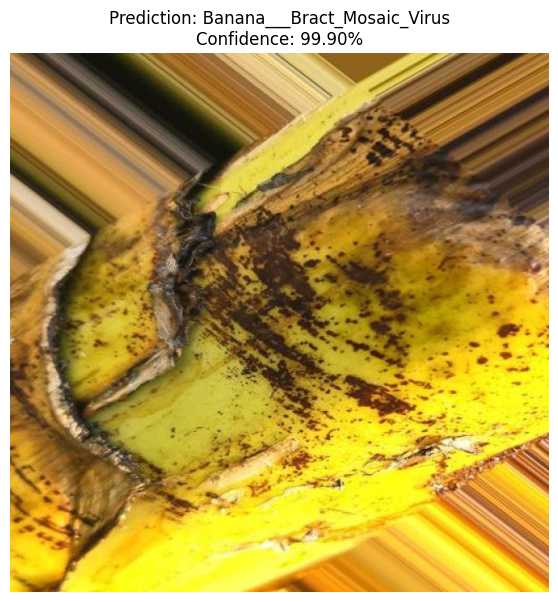

        CROP DISEASE PREDICTION
Image       : mendeley__Banana___Bract_Mosaic_Virus__0003502 (1).jpg
Prediction  : Banana___Bract_Mosaic_Virus
Confidence  : 99.90%


In [33]:
#Single-image prediction
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt

uploaded = files.upload()

image_path = next(iter(uploaded))

image = Image.open(image_path).convert("RGB")

input_tensor = eval_transform(image).unsqueeze(0).to(device)

model.eval()

with torch.no_grad():
    with torch.amp.autocast("cuda"):
        output = model(input_tensor)

probabilities = torch.softmax(output, dim=1)

confidence, predicted_idx = torch.max(probabilities, dim=1)

predicted_idx = predicted_idx.item()
confidence = confidence.item()

predicted_class = class_names[predicted_idx]

plt.figure(figsize=(7, 7))
plt.imshow(image)
plt.axis("off")
plt.title(
    f"Prediction: {predicted_class}\n"
    f"Confidence: {confidence*100:.2f}%"
)
plt.show()

print("====================================")
print("        CROP DISEASE PREDICTION")
print("====================================")
print(f"Image       : {image_path}")
print(f"Prediction  : {predicted_class}")
print(f"Confidence  : {confidence*100:.2f}%")
print("====================================")

In [34]:
#Top-5 predictions
top5_prob, top5_idx = torch.topk(probabilities, 5)

print("\nTop-5 Predictions:")
print("------------------------------------")

for rank, (prob, idx) in enumerate(
    zip(top5_prob[0], top5_idx[0]), start=1
):
    print(
        f"{rank}. {class_names[idx.item()]:50s} "
        f"{prob.item()*100:.2f}%"
    )


Top-5 Predictions:
------------------------------------
1. Banana___Bract_Mosaic_Virus                        99.90%
2. Banana___Yellow_Sigatoka                           0.07%
3. Banana___Panama_Disease                            0.03%
4. Banana___Insect_Pest                               0.00%
5. Cotton___Bacterial_Blight                          0.00%
